In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, classification_report

In [5]:
pip install polars

Note: you may need to restart the kernel to use updated packages.


In [6]:
import polars as pl

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Training on: cuda
GPU: NVIDIA A100-SXM4-80GB


In [8]:
# plot helper
def plot_histogram(df, column, bins=50, title=None, xlabel=None, ylabel="Frequency", yscale ='linear'):
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    plt.figure()
    plt.hist(df[column], bins=bins, edgecolor='black')
    plt.title(title or f"Histogram of {column}")
    plt.xlabel(xlabel or column)
    plt.ylabel(ylabel)
    plt.yscale(yscale)
    plt.grid(True)
    plt.show()

def plot_histogram_by_type(df, value_column, type_column="type", bins=50, alpha=0.7, filename = 'default_file', title = None):
    if value_column not in df.columns or type_column not in df.columns:
        raise ValueError(f"Columns '{value_column}' and/or '{type_column}' not found in DataFrame.")

    # Compute shared bin edges from entire column
    data = df[value_column].dropna()
    bin_edges = np.linspace(data.min(), data.max(), bins + 1)

    plt.figure(figsize=(8, 6))

    for t in df[type_column].unique():
        subset = df[df[type_column] == t][value_column].dropna()
        plt.hist(subset, bins=bin_edges, alpha=alpha, label=t, edgecolor='black', histtype='stepfilled')

    plt.xlabel(value_column)
    plt.ylabel("Frequency")
    plt.yscale('log')
    title = title or f"Histogram of {value_column} by {type_column} from {filename}"
    plt.title(title)
    plt.legend(title=type_column)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [9]:
df_sig = pl.read_parquet("df_sig_cleaned_noMu.parquet").to_pandas()
df_bkg = pl.read_parquet("df_bkg_cleaned_noMu.parquet").to_pandas()
print(df_sig.head())
print(df_bkg.head())

   numOfInDetTracks  numOfFatJets    fatJetPt  fatJetEta  fatJetPhi  \
0               394             2  205.005264  -1.798473  -3.124833   
1               563             3  279.483215   1.632125  -1.336066   
2               513             4  196.928345   0.558807  -2.093046   
3               716             2  330.735748  -0.577842  -1.053193   
4               718             2  352.341370  -0.517258  -0.063766   

     fatJetM  fatJetD2      jet1Pt   jet1Eta   jet1Phi  ...  fj_track21relPt  \
0  12.640295  4.901887  266.753174 -1.783698 -0.183333  ...         0.003333   
1  88.093224  1.698628  303.077393  3.060815  1.711246  ...         0.023212   
2  68.593727  2.024270  309.210968  1.321458 -0.102276  ...         0.010754   
3  56.575325  1.152085  377.495972 -0.062967  2.288692  ...         0.005826   
4  61.902214  1.359048  753.384399  1.898749  3.090093  ...         0.005494   

   fj_track22relPt  fj_track23relPt  fj_track24relPt  fj_track25relPt  \
0         0.003125 

In [10]:
df_sig = df_sig[df_sig['fatJetPt']>200]
df_bkg = df_bkg[df_bkg['fatJetPt']>200]

In [11]:
df_sig = df_sig[df_sig['muon_fatjet_dr']<1]

In [12]:
df_bkg = df_bkg[df_bkg['muon_fatjet_dr']<1]


In [13]:
df_sig = df_sig[df_sig['fatJetM']>40]
df_bkg = df_bkg[df_bkg['fatJetM']>40]

In [14]:
import pandas as pd
import numpy as np

def delta_phi(phi1, phi2):
    """Calculates dPhi and wraps it strictly between -pi and pi."""
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2 * np.pi) - np.pi

def delta_r(eta1, eta2, phi1, phi2):
    """Calculates standard dR."""
    deta = eta1 - eta2
    dphi = delta_phi(phi1, phi2)
    return np.sqrt(deta**2 + dphi**2)

def sort_jets_by_dr(df):
    """
    Computes dR for jet1 and jet2 relative to the fat jet.
    Swaps jet1 and jet2 properties so that jet1 always has the larger dR.
    """
    # Create a copy to avoid SettingWithCopyWarnings
    df = df.copy()

    # 1. Compute dR for jet1 and jet2 relative to fatJet
    dR1 = delta_r(df['jet1Eta'], df['fatJetEta'], df['jet1Phi'], df['fatJetPhi'])
    dR2 = delta_r(df['jet2Eta'], df['fatJetEta'], df['jet2Phi'], df['fatJetPhi'])

    # 2. Create a boolean mask identifying exactly which rows need swapping.
    # We want decreasing order (jet1_dR >= jet2_dR). 
    # Therefore, we swap where dR1 < dR2.
    swap_mask = dR1 < dR2

    # 3. Define the base variables that need to be swapped
    variables_to_swap = ['Pt', 'Eta', 'Phi', 'M']

    # 4. Perform the swap using np.where for blazing fast vectorization
    for var in variables_to_swap:
        j1_col = f'jet1{var}'
        j2_col = f'jet2{var}'
        
        # Store original jet1 values temporarily
        temp_j1 = df[j1_col].copy()
        
        # Where swap_mask is True, assign jet2's value to jet1. Otherwise, keep jet1.
        df[j1_col] = np.where(swap_mask, df[j2_col], df[j1_col])
        
        # Where swap_mask is True, assign the ORIGINAL jet1's value to jet2. Otherwise, keep jet2.
        df[j2_col] = np.where(swap_mask, temp_j1, df[j2_col])

    # 5. Optional but highly recommended: Save the correctly sorted dR values directly 
    # to the dataframe so you don't have to recompute them later!
    df['jet1_fatJet_dR'] = np.where(swap_mask, dR2, dR1)
    df['jet2_fatJet_dR'] = np.where(swap_mask, dR1, dR2)

    return df

In [15]:
# df_sig_sorted = sort_jets_by_dr(df_sig)
# df_bkg_sorted = sort_jets_by_dr(df_bkg)

In [16]:
# Filter out the dummy -999 values
df_sig = df_sig[df_sig['fatJetD2'] != -999]
df_bkg = df_bkg[df_bkg['fatJetD2'] != -999]

# # Quick check to see how many rows were dropped
# print(f"Signal events remaining: {len(df_sig_sorted)}")
# print(f"Background events remaining: {len(df_bkg_sorted)}")

In [17]:
# print("dr <1 cut")
# df_sig_dr_1 = df_sig_sorted[df_sig_sorted['muon_fatjet_dr']<1.0]

# print("sig_event_loss = ", 1-(len(df_sig_dr_1)/len(df_sig_sorted)), "sig_event_count =", len(df_sig_dr_1))
# df_bkg_dr_1 = df_bkg_sorted[df_bkg_sorted['muon_fatjet_dr']<1.0]

# print("sig_event_loss =", 1-(len(df_bkg_dr_1)/len(df_bkg_sorted)), "bkg_event_count =", len(df_bkg_dr_1))

In [18]:
if 'weight' in df_sig.keys() and 'weight' in df_bkg.keys():
    print("lalal")

    N_total = len(df_sig)+len(df_bkg)
    
    # 2. Calculate the current sums
    sum_w_sig = np.sum(df_sig['weight'])
    sum_w_bkg = np.sum(df_bkg['weight'])
    
    # 3. Scale them so each class sums to N_total / 2
    df_sig['weight'] = df_sig['weight'] * ((N_total / 2.0) / sum_w_sig)
    df_bkg['weight'] = df_bkg['weight'] * ((N_total / 2.0) / sum_w_bkg)
    
    # --- Verification ---
    print(f"Sum of Signal weights: {np.sum(df_sig['weight']):.1f}") # Should be N/2
    print(f"Sum of Bkg weights: {np.sum(df_bkg['weight']):.1f}")    # Should be N/2


    
else:    
    print("no weight available")
    sig_wt = (len(df_sig)+len(df_bkg))/len(df_sig)/2
    bkg_wt = (len(df_sig)+len(df_bkg))/len(df_bkg)/2
    df_sig['weight'] = sig_wt
    df_bkg['weight'] = bkg_wt

no weight available


In [19]:
# old version

In [20]:
def delta_phi_numpy(phi1, phi2):
    dphi = np.asarray(phi1) - np.asarray(phi2)
    dphi = np.where(dphi > np.pi, dphi - 2 * np.pi, dphi)
    dphi = np.where(dphi < -np.pi, dphi + 2 * np.pi, dphi)
    return dphi

def load_and_process_new_dataset(df, label_val, weight_scale=None, dr_threshold=1.5, dnn_features=None):
    """
    Processes the new flattened dataset for the combined GDNN model.
    """
    print(f"Initial events: {len(df)}")
    
    # --- 1. Event Filtering ---
    if 'muon_fatjet_dr' in df.columns:
        df = df[df['muon_fatjet_dr'] < dr_threshold].copy()
        print(f"  -> Events after muon_fatjet_dr < {dr_threshold} filter: {len(df)}")
    
    df = df.fillna(0.0).reset_index(drop=True)

    # --- 2. DNN Feature Engineering (Relative Geometry) ---
    
    # Jet 1 relative to Muon
    df['muon_jet1_deta'] = df['muonEta'] - df['jet1Eta']
    df['muon_jet1_dphi'] = delta_phi_numpy(df['muonPhi'], df['jet1Phi'])
    df['muon_jet1_dr'] = np.sqrt(df['muon_jet1_deta']**2 + df['muon_jet1_dphi']**2)

    # Jet 2 relative to Muon
    df['muon_jet2_deta'] = df['muonEta'] - df['jet2Eta']
    df['muon_jet2_dphi'] = delta_phi_numpy(df['muonPhi'], df['jet2Phi'])
    df['muon_jet2_dr'] = np.sqrt(df['muon_jet2_deta']**2 + df['muon_jet2_dphi']**2)

    # MET relative to Muon and FatJet
    df['muon_MET_dphi'] = delta_phi_numpy(df['muonPhi'], df['METPhi'])
    df['fatjet_MET_dphi'] = delta_phi_numpy(df['fatJetPhi'], df['METPhi'])

    # --- 3. GNN Tensor Construction ---
    MAX_TRACKS = 30
    pts = np.zeros((len(df), MAX_TRACKS))
    etas = np.zeros((len(df), MAX_TRACKS))
    phis = np.zeros((len(df), MAX_TRACKS))
    
    for i in range(1, MAX_TRACKS + 1):
        if f'fj_track{i}Pt' in df.columns:
            pts[:, i-1] = df[f'fj_track{i}Pt'].values
            etas[:, i-1] = df[f'fj_track{i}Eta'].values
            phis[:, i-1] = df[f'fj_track{i}Phi'].values
            
    # Extract FatJet kinematics and expand dimensions for broadcasting to (N_events, 1)
    fatJetPt = df['fatJetPt'].values[:, np.newaxis]
    fatJetEta = df['fatJetEta'].values[:, np.newaxis]
    fatJetPhi = df['fatJetPhi'].values[:, np.newaxis]
    
    # Create a mask to identify real tracks vs. padded zeros
    valid_mask = (pts != 0)
    
    # 1. Compute Relative Pt (Constituent Pt / FatJet Pt)
    rel_pts = np.divide(pts, fatJetPt, out=np.zeros_like(pts), where=(fatJetPt!=0))
    
    # 2. Compute delta Eta (detas)
    detas = etas - fatJetEta
    detas = np.where(valid_mask, detas, 0.0)
    
    # 3. Compute delta Phi (dphis) and wrap bounded to [-pi, pi]
    dphis = phis - fatJetPhi
    dphis = (dphis + np.pi) % (2 * np.pi) - np.pi
    dphis = np.where(valid_mask, dphis, 0.0)
    
    # 4. Compute delta R (drs)
    drs = np.sqrt(detas**2 + dphis**2)
    drs = np.where(valid_mask, drs, 0.0)
    
    # GNN Shape: (N_events, MAX_TRACKS, 4) -> Assuming MAX_TRACKS is 30
    X_gnn = np.stack([rel_pts, detas, dphis, drs], axis=-1).astype(np.float32)
    # --- 4. DNN Feature Selection & Tensor Construction ---
    if dnn_features is not None:
        missing = [c for c in dnn_features if c not in df.columns]
        if missing:
            print(f"  Note: Missing requested DNN columns (filled with 0): {missing}")
            for c in missing:
                df[c] = 0.0
        
        X_dnn = df[dnn_features].values.astype(np.float32)
        print(f"  -> Selected {len(dnn_features)} specific DNN features.")
    else:
        # Fallback
        dnn_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        X_dnn = df[dnn_cols].values.astype(np.float32)

    # --- 5. Finalize Labels, Weights, and IDs ---
    n_events = len(df)
    y = np.full(n_events, label_val, dtype=np.float32)
    
    if weight_scale is None:
        w = df['weight'].values
    else:
        w = np.full(n_events, weight_scale, dtype=np.float32)
    
    if 'event_index' in df.columns:
        ids = df['event_index'].values
    else:
        ids = np.arange(n_events)

    print(f"  -> Finished formatting: GNN shape: {X_gnn.shape}, DNN shape: {X_dnn.shape}")
    
    return X_gnn, X_dnn, y, w, ids

In [21]:
# # NEW version with reordered GNN
# # Helper function for angle wrapping
# def delta_phi_numpy(phi1, phi2):
#     dphi = np.asarray(phi1) - np.asarray(phi2)
#     dphi = np.where(dphi > np.pi, dphi - 2 * np.pi, dphi)
#     dphi = np.where(dphi < -np.pi, dphi + 2 * np.pi, dphi)
#     return dphi

# def load_and_process_new_dataset(df, label_val, weight_scale=None, dr_threshold=1.5, dnn_features=None):
#     """
#     Processes the new flattened dataset for the combined GDNN model.
#     Tracks are sorted based on (rel_pt^2 + (1-dr)^2).
#     """
#     print(f"Initial events: {len(df)}")
    
#     # --- 1. Event Filtering ---
#     if 'muon_fatjet_dr' in df.columns:
#         df = df[df['muon_fatjet_dr'] < dr_threshold].copy()
#         print(f"  -> Events after muon_fatjet_dr < {dr_threshold} filter: {len(df)}")
    
#     df = df.fillna(0.0).reset_index(drop=True)

#     # --- 2. DNN Feature Engineering (Relative Geometry) ---
    
#     # Jet 1 relative to Muon
#     df['muon_jet1_deta'] = df['muonEta'] - df['jet1Eta']
#     df['muon_jet1_dphi'] = delta_phi_numpy(df['muonPhi'], df['jet1Phi'])
#     df['muon_jet1_dr'] = np.sqrt(df['muon_jet1_deta']**2 + df['muon_jet1_dphi']**2)

#     # Jet 2 relative to Muon
#     df['muon_jet2_deta'] = df['muonEta'] - df['jet2Eta']
#     df['muon_jet2_dphi'] = delta_phi_numpy(df['muonPhi'], df['jet2Phi'])
#     df['muon_jet2_dr'] = np.sqrt(df['muon_jet2_deta']**2 + df['muon_jet2_dphi']**2)

#     # MET relative to Muon and FatJet
#     df['muon_MET_dphi'] = delta_phi_numpy(df['muonPhi'], df['METPhi'])
#     df['fatjet_MET_dphi'] = delta_phi_numpy(df['fatJetPhi'], df['METPhi'])

#     # --- 3. GNN Tensor Construction & Sorting ---
#     MAX_TRACKS = 30
#     pts = np.zeros((len(df), MAX_TRACKS))
#     detas = np.zeros((len(df), MAX_TRACKS))
#     dphis = np.zeros((len(df), MAX_TRACKS))
#     drs = np.zeros((len(df), MAX_TRACKS))
    
#     for i in range(1, MAX_TRACKS + 1):
#         if f'fj_track{i}Pt' in df.columns:
#             pts[:, i-1] = df[f'fj_track{i}Pt'].values
#             detas[:, i-1] = df[f'fj_track{i}dEta'].values
#             dphis[:, i-1] = df[f'fj_track{i}dPhi'].values
#             drs[:, i-1] = df[f'fj_track{i}dR'].values

#     # GNN Shape: (N_events, 30, 4)
#     X_gnn = np.stack([pts, detas, dphis, drs], axis=-1).astype(np.float32)

#     # --- 4. DNN Feature Selection & Tensor Construction ---
#     if dnn_features is not None:
#         missing = [c for c in dnn_features if c not in df.columns]
#         if missing:
#             print(f"  Note: Missing requested DNN columns (filled with 0): {missing}")
#             for c in missing:
#                 df[c] = 0.0
        
#         X_dnn = df[dnn_features].values.astype(np.float32)
#         print(f"  -> Selected {len(dnn_features)} specific DNN features.")
#     else:
#         # Fallback
#         dnn_cols = df.select_dtypes(include=[np.number]).columns.tolist()
#         X_dnn = df[dnn_cols].values.astype(np.float32)

#     # --- 5. Finalize Labels, Weights, and IDs ---
#     n_events = len(df)
#     y = np.full(n_events, label_val, dtype=np.float32)
    
#     if weight_scale is None:
#         w = df['weight'].values
#     else:
#         w = np.full(n_events, weight_scale, dtype=np.float32)
    
#     if 'event_index' in df.columns:
#         ids = df['event_index'].values
#     else:
#         ids = np.arange(n_events)

#     print(f"  -> Finished formatting: GNN shape: {X_gnn.shape}, DNN shape: {X_dnn.shape}")
    
#     return X_gnn, X_dnn, y, w, ids

In [22]:

my_dnn_features = [
    # Global / Track Counts
    # 'numOfInDetTracks_inFJCone', 'fatJetD2',
    
    # Muon Base Kinematics (Keeping Eta as the spatial reference point)
    'muonPt', 'muonEta', 
    
    # FatJet Base Kinematics
    'fatJetPt', 'fatJetM', 'fatJetEta', 
    
    # Small Jets Base Kinematics
    'jet1Pt', 'jet1M','jet2Pt', 'jet2M',
    
    # MET Base
    'MET',
    
    # Pre-existing Relative Geometries
    'muon_fatjet_dr', 'muon_fatjet_deta', 'muon_fatjet_dphi',
    
    # Newly Engineered Relative Geometries
    'muon_jet1_dr', 'muon_jet1_deta', 'muon_jet1_dphi',
    
    'muon_jet2_dr', 'muon_jet2_deta', 'muon_jet2_dphi',
    
    'muon_MET_dphi', 'fatjet_MET_dphi'
]

# 3. Process the data
xg_sig, xd_sig, y_sig, w_sig, id_sig = load_and_process_new_dataset(
    df_sig, 
    label_val=1, 
    weight_scale=None, 
    dr_threshold=1.0, 
    dnn_features=my_dnn_features
)

xg_bg, xd_bg, y_bg, w_bg, id_bg = load_and_process_new_dataset(
    df_bkg, 
    label_val=0, 
    weight_scale=None, 
    dr_threshold=1.0, 
    dnn_features=my_dnn_features
)

# 4. Concatenate and move to your PyTorch DataLoader
X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
X_dnn_all = np.concatenate([xd_sig, xd_bg], axis=0)

Initial events: 116824
  -> Events after muon_fatjet_dr < 1.0 filter: 116824
  -> Selected 21 specific DNN features.
  -> Finished formatting: GNN shape: (116824, 30, 4), DNN shape: (116824, 21)
Initial events: 77246
  -> Events after muon_fatjet_dr < 1.0 filter: 77246
  -> Selected 21 specific DNN features.
  -> Finished formatting: GNN shape: (77246, 30, 4), DNN shape: (77246, 21)


In [23]:
SCORED_PARQUET_SIG = "sig_reco_large.parquet"
SCORED_PARQUET_BKG = "bkg_reco_large.parquet"

In [24]:
# DNN

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import time
import os

OUTPUT_DIR = 'dnn_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128

# 1. Finish Concatenation
y_all = np.concatenate([y_sig, y_bg], axis=0)
w_all = np.concatenate([w_sig, w_bg], axis=0)
# id_all = np.concatenate([id_sig, id_bg], axis=0) # If you need to track IDs

print(f"Total dataset size: {len(y_all)} events")

# 2. Scale DNN Features
scaler_dnn = StandardScaler()
X_dnn_all_scaled = scaler_dnn.fit_transform(X_dnn_all)

# 3. Data Splitting (Train 80% / Val 10% / Test 10%)
indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# 4. PyTorch Datasets
train_ds = TensorDataset(
    torch.tensor(X_dnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.tensor(y_all[train_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[train_idx], dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.tensor(X_dnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.tensor(y_all[val_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[val_idx], dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.tensor(X_dnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.tensor(y_all[test_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[test_idx], dtype=torch.float32).view(-1, 1)
)

# 5. DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)

Total dataset size: 194070 events


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
# Make sure to import the scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau 

class DNN_Only(nn.Module):
    def __init__(self, input_dim):
        super(DNN_Only, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), 
            nn.ReLU(), 
            nn.BatchNorm1d(128), 
            nn.Dropout(0.15),
            
            nn.Linear(128, 64), 
            nn.ReLU(), 
            nn.BatchNorm1d(64), 
            nn.Dropout(0.15),
            
            nn.Linear(64, 32), 
            nn.ReLU(),
            
            nn.Linear(32, 1) # Outputs logits
        )
        
    def forward(self, x):
        return self.net(x)

# Initialize Model
input_features = X_dnn_all_scaled.shape[1] # Should be 25
dnn_model = DNN_Only(input_dim=input_features).to(DEVICE)

# Compile for A100 speedup (Optional but recommended)
try:
    dnn_model = torch.compile(dnn_model)
    print("Model compiled successfully.")
except Exception as e:
    print(f"Skipping torch.compile: {e}")

optimizer = optim.Adam(dnn_model.parameters(), lr=0.001)

# --- NEW: Initialize the Scheduler ---
# mode='min': We want to reduce LR when the metric (val_loss) stops decreasing.
# factor=0.5: When triggered, the new LR will be LR * 0.5.
# patience=2: Wait 2 epochs of no improvement before dropping the LR.
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=2)

scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    return (loss * weight).mean()


print("\nStarting DNN Training...")
EPOCHS = 80 
best_val_loss = float('inf')
patience = 6
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- Training ---
    dnn_model.train()
    train_loss = 0
    
    for x_batch, y_batch, w_batch in train_loader:
        x_batch = x_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = dnn_model(x_batch)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * x_batch.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation ---
    dnn_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x_batch, y_batch, w_batch in val_loader:
            x_batch = x_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                out = dnn_model(x_batch)
                loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * x_batch.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # --- NEW: Step the Scheduler ---
    # Pass the validation loss to the scheduler so it can check for plateaus
    scheduler.step(val_loss)
    
    # Grab the current learning rate from the optimizer to print it
    current_lr = optimizer.param_groups[0]['lr']
    
    # Updated print statement to show the current learning rate
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    # --- Early Stopping Logic ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(dnn_model.state_dict(), f"{OUTPUT_DIR}/best_dnn_only.pth")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped at epoch {epoch+1}.")
            break

print("Training Complete!")

Model compiled successfully.

Starting DNN Training...
Epoch [1/80] | Train Loss: 0.4435 | Val Loss: 0.3983 | LR: 0.001000 | Time: 9.0s
Epoch [2/80] | Train Loss: 0.3883 | Val Loss: 0.3542 | LR: 0.001000 | Time: 6.5s
Epoch [3/80] | Train Loss: 0.3619 | Val Loss: 0.3433 | LR: 0.001000 | Time: 6.5s
Epoch [4/80] | Train Loss: 0.3521 | Val Loss: 0.3348 | LR: 0.001000 | Time: 6.8s
Epoch [5/80] | Train Loss: 0.3465 | Val Loss: 0.3271 | LR: 0.001000 | Time: 6.5s
Epoch [6/80] | Train Loss: 0.3426 | Val Loss: 0.3262 | LR: 0.001000 | Time: 6.5s
Epoch [7/80] | Train Loss: 0.3393 | Val Loss: 0.3258 | LR: 0.001000 | Time: 6.5s
Epoch [8/80] | Train Loss: 0.3372 | Val Loss: 0.3221 | LR: 0.001000 | Time: 6.4s
Epoch [9/80] | Train Loss: 0.3351 | Val Loss: 0.3233 | LR: 0.001000 | Time: 6.6s
  -> No improvement for 1 epoch(s).
Epoch [10/80] | Train Loss: 0.3320 | Val Loss: 0.3201 | LR: 0.001000 | Time: 7.4s
Epoch [11/80] | Train Loss: 0.3321 | Val Loss: 0.3161 | LR: 0.001000 | Time: 8.0s
Epoch [12/80] | 


Evaluating best model on Test Set...


/tmp/ipykernel_23694/3759747683.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_dnn_only.pth"))



FINAL PERFORMANCE ON TEST SET (with event weights)
              precision    recall  f1-score   support

  Background       0.89      0.84      0.86 9704.00284230709
      Signal       0.85      0.90      0.87 9703.167650341988

    accuracy                           0.87 19407.17049264908
   macro avg       0.87      0.87      0.87 19407.17049264908
weighted avg       0.87      0.87      0.87 19407.17049264908



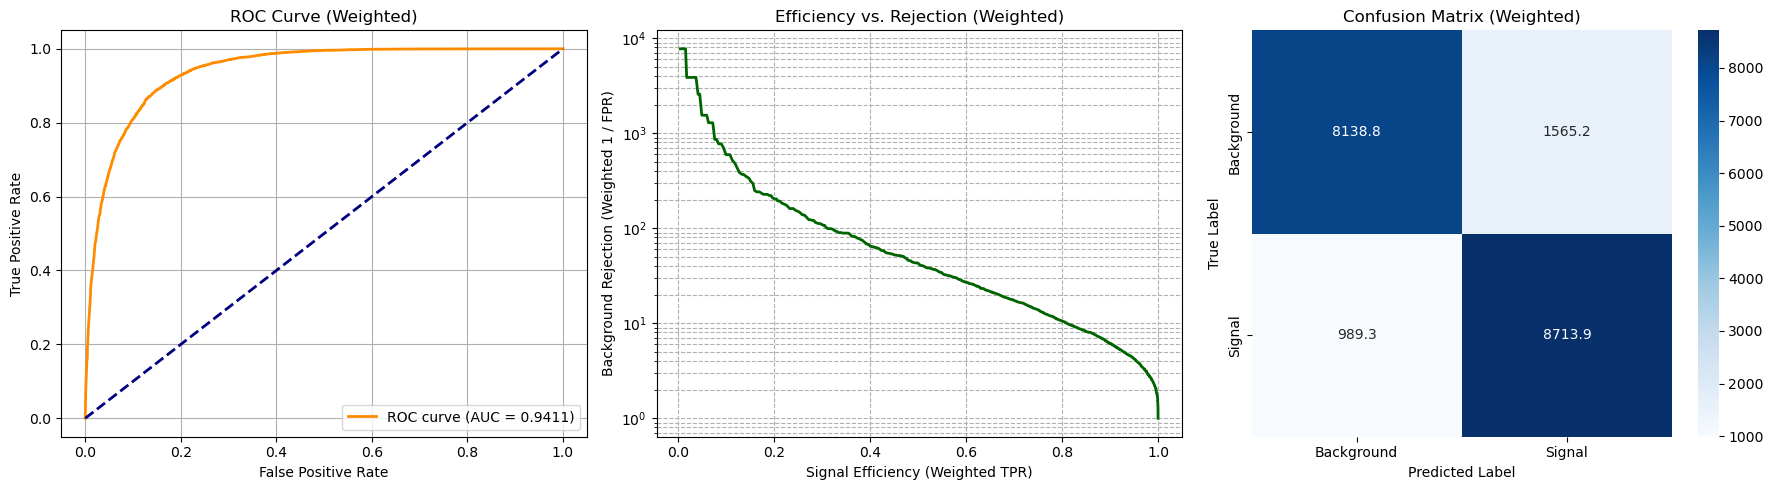


SCORING AND SAVING FULL DATASETS
Generating scores for 116824 events...


/tmp/ipykernel_23694/3759747683.py:130: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_dnn_only.pth"))


 -> Saved successfully to: dnn_results/df_sig_reco_m_cut_no_sub.parquet
Generating scores for 77246 events...
 -> Saved successfully to: dnn_results/df_bkg_reco_m_cut_no_sub.parquet

All processing complete.


In [27]:
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# ==========================================
# 4. Evaluation Function
# ==========================================
def evaluate_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  # Set model to evaluation mode
    all_labels = []
    all_probas = []
    all_weights = [] # Collect weights for evaluation metrics if needed

    with torch.no_grad():
        for inputs, labels, weights in data_loader:
            inputs = inputs.to(device)
            
            # Use autocast for mixed precision evaluation
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                # Apply sigmoid since the model outputs logits
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) # Collect weights

    # Flatten arrays for scikit-learn functions
    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten()

    # 1. Performance Statistics (using sample_weight)
    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET (with event weights)\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    # 2. ROC Curve (using sample_weight)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Weighted)')
    plt.legend(loc="lower right")
    plt.grid(True)

    # 3. Signal Efficiency vs. Background Rejection (calculated from weighted FPR/TPR)
    # Avoid division by zero warnings
    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
        
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log')
    plt.xlabel('Signal Efficiency (Weighted TPR)')
    plt.ylabel('Background Rejection (Weighted 1 / FPR)')
    plt.title('Efficiency vs. Rejection (Weighted)')
    plt.grid(True, which="both", ls="--")

    # 4. Confusion Matrix (using sample_weight)
    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

# --- Execution ---
print("\nEvaluating best model on Test Set...")
# Load the best weights saved by the early stopping mechanism
dnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_dnn_only.pth"))

# Call the function
evaluate_model(dnn_model, test_loader, DEVICE)

# 5. Score Entire Datasets and Save to Parquet
# ==========================================
import os

def score_and_save_dataset(df, X_dnn_raw, scaler, model, device, output_path, batch_size=BATCH_SIZE):
    """
    Applies the trained model to the full dataset, adds the scores as a new column,
    and saves the result to a Parquet file.
    """
    print(f"Generating scores for {len(df)} events...")
    
    # 1. Scale the raw features using the ALREADY FITTED scaler
    X_scaled = scaler.transform(X_dnn_raw)
    
    # 2. Create a DataLoader for batch processing (safeguard against GPU OOM)
    tensor_ds = TensorDataset(torch.tensor(X_scaled, dtype=torch.float32))
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    # 3. Get predictions
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for (inputs,) in loader:
            inputs = inputs.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    # 4. Add the scores to a copy of the dataframe
    df_scored = df.copy() 
    df_scored['dnn_score'] = np.array(all_probas).flatten()
    
    # 5. Save to Parquet
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS\n" + "="*60)

# Ensure the model is using the best weights
dnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_dnn_only.pth"))

# Score Signal Dataset
# Note: df_sig_dr_1 and xd_sig are from your earlier load_and_process_new_dataset calls
df_sig_scored = score_and_save_dataset(
    df=df_sig, 
    X_dnn_raw=xd_sig, 
    scaler=scaler_dnn, 
    model=dnn_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_SIG),
    batch_size=BATCH_SIZE
)

# Score Background Dataset
df_bkg_scored = score_and_save_dataset(
    df=df_bkg, 
    X_dnn_raw=xd_bg, 
    scaler=scaler_dnn, 
    model=dnn_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_BKG),
    batch_size=BATCH_SIZE
)

print("\nAll processing complete.")




In [ ]:
#GNN Model

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

OUTPUT_DIR = 'gnn_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ==========================================
# 1. GNN Data Preparation & Scaling
# ==========================================
# Assuming xg_sig, xg_bg, y_sig, y_bg, w_sig, w_bg are in memory
X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
y_all = np.concatenate([y_sig, y_bg], axis=0)
w_all = np.concatenate([w_sig, w_bg], axis=0)

print(f"Total GNN dataset size: {len(y_all)} events")

# Scale GNN Features (Masking out zero-padded particles)
N, M, F = X_gnn_all.shape
X_gnn_flat = X_gnn_all.reshape(-1, F)
is_real = ~np.all(X_gnn_flat == 0, axis=1) # Boolean mask for real tracks

scaler_gnn = StandardScaler()
# Fit only on real particles
scaler_gnn.fit(X_gnn_flat[is_real])
# Transform real particles
X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
# Ensure padding remains exactly zero
X_gnn_flat[~is_real] = 0 

X_gnn_all_scaled = X_gnn_flat.reshape(N, M, F)

# Data Splitting (Train 80% / Val 10% / Test 10%)
# Using same random_state=42 ensures the splits perfectly match the DNN splits later!
indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# PyTorch Datasets
train_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.tensor(y_all[train_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[train_idx], dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.tensor(y_all[val_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[val_idx], dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.tensor(y_all[test_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[test_idx], dtype=torch.float32).view(-1, 1)
)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)

Total GNN dataset size: 194070 events


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
# Make sure to import the scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau 

# ==========================================
# 2. Model Definition
# ==========================================
# --- Model Definition (Interaction Network) ---
def create_interaction_matrices(n_particles):
    # Receiver Matrix (RR) [N, N(N-1)]
    RR = np.zeros((n_particles, n_particles * (n_particles - 1)), dtype=np.float32)
    # Sender Matrix (RS) [N, N(N-1)]
    RS = np.zeros((n_particles, n_particles * (n_particles - 1)), dtype=np.float32)
    
    cnt = 0
    for i in range(n_particles):
        for j in range(n_particles):
            if i != j:
                RR[i, cnt] = 1.0
                RS[j, cnt] = 1.0
                cnt += 1
    return torch.tensor(RR), torch.tensor(RS)

class InteractionNetwork(nn.Module):
    def __init__(self, n_particles, n_features, output_dim=1):
        super(InteractionNetwork, self).__init__()
        
        # Interaction Matrices
        RR, RS = create_interaction_matrices(n_particles)
        self.register_buffer('RR', RR)
        self.register_buffer('RS', RS)
        
        # --- Relational Model (Edge Function) ---
        self.rel_layer1 = nn.Sequential(nn.Linear(2 * n_features, 80), nn.ReLU())
        self.rel_layer2 = nn.Sequential(nn.Linear(80, 50), nn.ReLU())
        self.rel_layer3 = nn.Sequential(nn.Linear(50, 30), nn.ReLU())
        self.rel_bn = nn.BatchNorm1d(30)
        
        # --- Object Model (Node Function) ---
        self.obj_layer1 = nn.Sequential(nn.Linear(n_features + 30, 80), nn.ReLU())
        self.obj_layer2 = nn.Sequential(nn.Linear(80, 50), nn.ReLU())
        self.obj_layer3 = nn.Sequential(nn.Linear(50, 24), nn.ReLU())
        
        # --- Classifier (Global) ---
        self.cls_layer1 = nn.Sequential(nn.Linear(24, 60), nn.ReLU())
        self.cls_bn = nn.BatchNorm1d(60)
        self.cls_layer2 = nn.Sequential(nn.Linear(60, 30), nn.ReLU())
        self.cls_layer3 = nn.Sequential(nn.Linear(30, 10), nn.ReLU())
        self.cls_out = nn.Linear(10, output_dim) 

    def forward(self, x):
        # x: (Batch, N_particles, Features)
        
        # 1. Create Edge Features
        x_transpose = x.transpose(1, 2) # (B, F, N)
        receivers = torch.matmul(x_transpose, self.RR)
        senders = torch.matmul(x_transpose, self.RS)
        edges = torch.cat([receivers, senders], dim=1)
        edges = edges.transpose(1, 2) # (B, N_edges, 2*F)
        
        # 2. Relational Model
        e = self.rel_layer1(edges)
        e = self.rel_layer2(e)
        e = self.rel_layer3(e)
        
        # Apply BN to edges (B, N_edges, 30) -> Permute -> BN -> Permute
        e = e.transpose(1, 2) # (B, 30, N_edges)
        e = self.rel_bn(e)
        e = e.transpose(1, 2) # (B, N_edges, 30)
        
        # 3. Aggregate
        effect_agg = torch.matmul(e.transpose(1, 2), self.RR.t())
        effect_agg = effect_agg.transpose(1, 2) # (B, N, 30)
        
        # 4. Object Model
        node_input = torch.cat([x, effect_agg], dim=2)
        node = self.obj_layer1(node_input)
        node = self.obj_layer2(node)
        node = self.obj_layer3(node) # (B, N, 24)
        
        # 5. Global Sum Pooling
        global_latent = torch.sum(node, dim=1) # (B, 24)
        
        # 6. Classifier (raw Logits)
        c = self.cls_layer1(global_latent)
        c = self.cls_bn(c)
        c = self.cls_layer2(c)
        c = self.cls_layer3(c)
        
        # Return RAW LOGITS (No Sigmoid here!) for numerical stability
        return self.cls_out(c)

# Initialize Model
# Features F=4 (rel_pt, dEta, dPhi, dR)
# DEVICE and OUTPUT_DIR should be defined elsewhere in your code
gnn_model = InteractionNetwork(n_particles=30, n_features=4).to(DEVICE)

try:
    gnn_model = torch.compile(gnn_model)
    print("GNN Model compiled successfully.")
except Exception as e:
    print(f"Skipping torch.compile.")

optimizer = optim.Adam(gnn_model.parameters(), lr=0.001)

# --- NEW: Initialize the Scheduler ---
# mode='min': Monitoring for decrease in val_loss
# factor=0.5: Halve the learning rate on plateau
# patience=3: Trigger after 3 epochs of no improvement (safely below early stopping patience of 8)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=2)

scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    return (loss * weight).mean()

# ==========================================
# 3. Training Loop with Early Stopping
# ==========================================
print("\nStarting GNN Training...")
EPOCHS = 100 
best_val_loss = float('inf')
patience = 6
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- Training ---
    gnn_model.train()
    train_loss = 0
    
    for x_batch, y_batch, w_batch in train_loader:
        x_batch = x_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = gnn_model(x_batch)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * x_batch.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation ---
    gnn_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x_batch, y_batch, w_batch in val_loader:
            x_batch = x_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            # REMOVED: with torch.amp.autocast('cuda'):
            # Run the forward pass in standard float32 for absolute stability
            out = gnn_model(x_batch)
            
            # Since everything is already float32, we can just calculate loss directly
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * x_batch.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # --- NEW: Step the Scheduler ---
    # Pass val_loss to check for plateau
    scheduler.step(val_loss)
    
    # Grab the current learning rate from the optimizer
    current_lr = optimizer.param_groups[0]['lr']
    
    # Updated print statement to show the current learning rate
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    # --- Early Stopping Logic ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(gnn_model.state_dict(), f"{OUTPUT_DIR}/best_gnn_only.pth")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped at epoch {epoch+1}.")
            break

print("Training Complete!")

GNN Model compiled successfully.

Starting GNN Training...
Epoch [1/100] | Train Loss: 0.6192 | Val Loss: 0.6081 | LR: 0.001000 | Time: 19.9s
Epoch [2/100] | Train Loss: 0.6045 | Val Loss: 0.6511 | LR: 0.001000 | Time: 13.9s
  -> No improvement for 1 epoch(s).
Epoch [3/100] | Train Loss: 0.5950 | Val Loss: 0.5987 | LR: 0.001000 | Time: 13.2s
Epoch [4/100] | Train Loss: 0.5881 | Val Loss: 0.6206 | LR: 0.001000 | Time: 12.7s
  -> No improvement for 1 epoch(s).
Epoch [5/100] | Train Loss: 0.5820 | Val Loss: 0.5978 | LR: 0.001000 | Time: 12.6s
Epoch [6/100] | Train Loss: 0.5781 | Val Loss: 0.5826 | LR: 0.001000 | Time: 13.2s
Epoch [7/100] | Train Loss: 0.5739 | Val Loss: 0.6106 | LR: 0.001000 | Time: 12.0s
  -> No improvement for 1 epoch(s).
Epoch [8/100] | Train Loss: 0.5706 | Val Loss: 0.5733 | LR: 0.001000 | Time: 12.5s
Epoch [9/100] | Train Loss: 0.5680 | Val Loss: 0.5688 | LR: 0.001000 | Time: 10.9s
Epoch [10/100] | Train Loss: 0.5651 | Val Loss: 0.5666 | LR: 0.001000 | Time: 10.9s
Ep


Evaluating best GNN model on Test Set...


/tmp/ipykernel_23694/1263796296.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gnn_only.pth"))



FINAL PERFORMANCE ON TEST SET (with event weights)
              precision    recall  f1-score   support

  Background       0.73      0.71      0.72 9704.00284230709
      Signal       0.72      0.73      0.73 9703.167650341988

    accuracy                           0.72 19407.17049264908
   macro avg       0.72      0.72      0.72 19407.17049264908
weighted avg       0.72      0.72      0.72 19407.17049264908



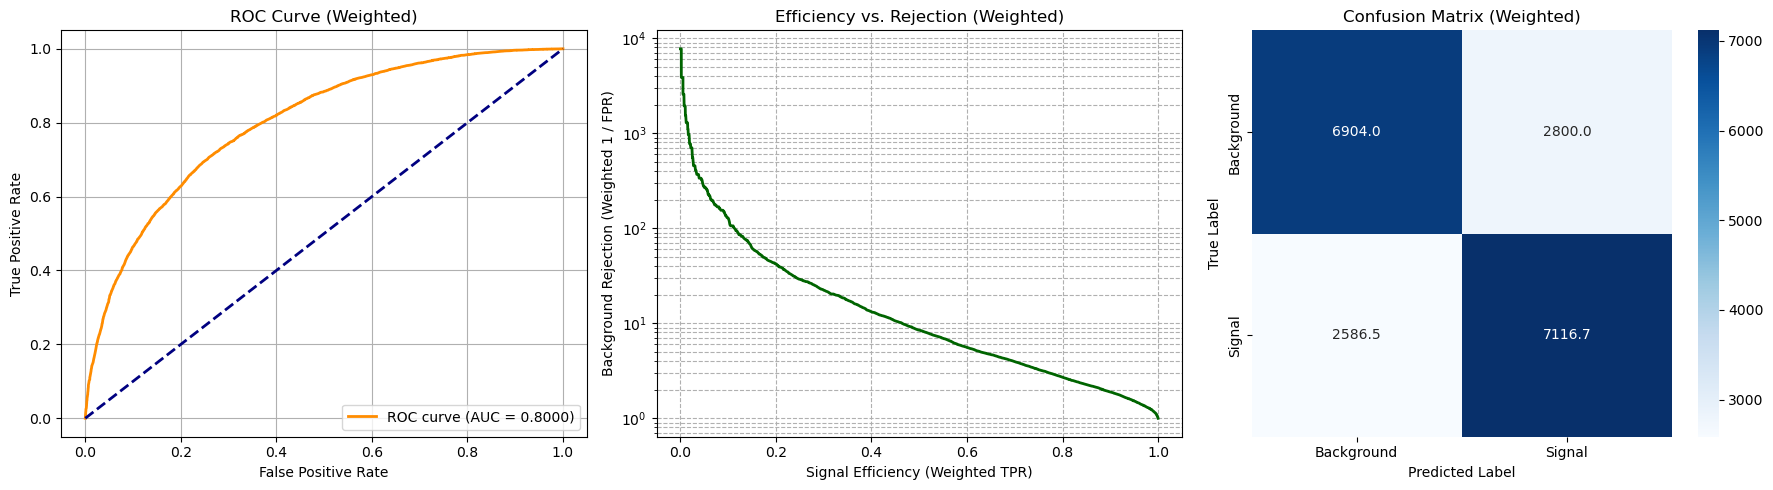


SCORING AND SAVING FULL DATASETS (GNN)
Generating GNN scores for 116824 events...


/tmp/ipykernel_23694/1263796296.py:122: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gnn_only.pth"))


 -> Saved successfully to: gnn_results/df_sig_reco_m_cut_no_sub.parquet
Generating GNN scores for 77246 events...
 -> Saved successfully to: gnn_results/df_bkg_reco_m_cut_no_sub.parquet

All GNN processing complete.


In [30]:
# ==========================================
# 4. Evaluation Function
# ==========================================
def evaluate_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  # Set model to evaluation mode
    all_labels = []
    all_probas = []
    all_weights = [] # Collect weights for evaluation metrics if needed

    with torch.no_grad():
        for inputs, labels, weights in data_loader:
            inputs = inputs.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) # Collect weights

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten() # Flatten weights for scikit-learn functions

    # 1. Performance Statistics (using sample_weight)
    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET (with event weights)\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    # 2. ROC Curve (using sample_weight)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve (Weighted)'); plt.legend(loc="lower right"); plt.grid(True)

    # 3. Signal Efficiency vs. Background Rejection (calculated from weighted FPR/TPR)
    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log'); plt.xlabel('Signal Efficiency (Weighted TPR)'); plt.ylabel('Background Rejection (Weighted 1 / FPR)'); plt.title('Efficiency vs. Rejection (Weighted)'); plt.grid(True, which="both", ls="--")

    # 4. Confusion Matrix (using sample_weight)
    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)'); plt.ylabel('True Label'); plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

# --- Execution ---
print("\nEvaluating best GNN model on Test Set...")
gnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gnn_only.pth"))

# Call the function
evaluate_model(gnn_model, test_loader, DEVICE)

# ==========================================
# 5. Score Entire Datasets and Save to Parquet
# ==========================================
import os

def score_and_save_gnn_dataset(df, X_gnn_raw, scaler, model, device, output_path, batch_size=BATCH_SIZE):
    """
    Applies the trained GNN model to the full dataset, adds the scores as a new column,
    and saves the result to a Parquet file.
    """
    print(f"Generating GNN scores for {len(df)} events...")
    
    # 1. Scale the raw features using the ALREADY FITTED scaler
    # Must replicate the masking logic used during training data prep
    N, M, F = X_gnn_raw.shape
    X_flat = X_gnn_raw.reshape(-1, F).copy()  # Copy to avoid modifying original array
    
    # Create mask for real tracks (not perfectly zeroed out)
    is_real = ~np.all(X_flat == 0, axis=1)
    
    # Apply transform only to real tracks
    if np.any(is_real):
        X_flat[is_real] = scaler.transform(X_flat[is_real])
        
    # Ensure padding remains exactly zero
    X_flat[~is_real] = 0.0 
    
    # Reshape back to (N_events, 30, 4)
    X_scaled = X_flat.reshape(N, M, F)
    
    # 2. Create a DataLoader for batch processing
    tensor_ds = TensorDataset(torch.tensor(X_scaled, dtype=torch.float32))
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    # 3. Get predictions
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for (inputs,) in loader:
            inputs = inputs.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    # 4. Add the scores to a copy of the dataframe
    df_scored = df.copy() 
    df_scored['gnn_score'] = np.array(all_probas).flatten()
    
    # 5. Save to Parquet
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS (GNN)\n" + "="*60)

# Ensure the model is using the best weights from Early Stopping
gnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gnn_only.pth"))

# Score Signal Dataset
# Assuming df_sig_dr_1 and xg_sig are in memory from your data processing step
df_sig_gnn_scored = score_and_save_gnn_dataset(
    df=df_sig_scored, 
    X_gnn_raw=xg_sig, 
    scaler=scaler_gnn, 
    model=gnn_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_SIG),
    batch_size=BATCH_SIZE
)

# Score Background Dataset
df_bkg_gnn_scored = score_and_save_gnn_dataset(
    df=df_bkg_scored, 
    X_gnn_raw=xg_bg, 
    scaler=scaler_gnn, 
    model=gnn_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_BKG),
    batch_size=BATCH_SIZE
)

print("\nAll GNN processing complete.")



In [ ]:
#GDNN

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

OUTPUT_DIR = 'gdnn_combined_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



# ==========================================
# 1. Combined Data Preparation
# ==========================================
# Assuming X_gnn_all_scaled, X_dnn_all_scaled, y_all, w_all are in memory
print(f"Total Combined dataset size: {len(y_all)} events")

indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# PyTorch Datasets (Yielding: x_gnn, x_dnn, y, w)
train_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.tensor(y_all[train_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[train_idx], dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.tensor(y_all[val_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[val_idx], dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.tensor(y_all[test_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[test_idx], dtype=torch.float32).view(-1, 1)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)

Total Combined dataset size: 194070 events


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
# --- NEW: Make sure to import the scheduler ---
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ==========================================
# 2. Model Definition
# ==========================================
class InteractionNetwork(nn.Module):
    def __init__(self, n_particles, n_features, output_latent_dim=24):
        super(InteractionNetwork, self).__init__()
        
        # Interaction Matrices
        RR = np.zeros((n_particles, n_particles * (n_particles - 1)), dtype=np.float32)
        RS = np.zeros((n_particles, n_particles * (n_particles - 1)), dtype=np.float32)
        cnt = 0
        for i in range(n_particles):
            for j in range(n_particles):
                if i != j:
                    RR[i, cnt] = 1.0
                    RS[j, cnt] = 1.0
                    cnt += 1
        self.register_buffer('RR', torch.tensor(RR))
        self.register_buffer('RS', torch.tensor(RS))
        
        # Relational Model
        self.rel_layer1 = nn.Sequential(nn.Linear(2 * n_features, 80), nn.ReLU())
        self.rel_layer2 = nn.Sequential(nn.Linear(80, 50), nn.ReLU())
        self.rel_layer3 = nn.Sequential(nn.Linear(50, 30), nn.ReLU())
        self.rel_bn = nn.BatchNorm1d(30)
        
        # Object Model
        self.obj_layer1 = nn.Sequential(nn.Linear(n_features + 30, 80), nn.ReLU())
        self.obj_layer2 = nn.Sequential(nn.Linear(80, 50), nn.ReLU())
        self.obj_layer3 = nn.Sequential(nn.Linear(50, output_latent_dim), nn.ReLU())
        
    def forward(self, x):
        x_transpose = x.transpose(1, 2)
        receivers = torch.matmul(x_transpose, self.RR)
        senders = torch.matmul(x_transpose, self.RS)
        edges = torch.cat([receivers, senders], dim=1).transpose(1, 2)
        
        e = self.rel_layer1(edges)
        e = self.rel_layer2(e)
        e = self.rel_layer3(e)
        
        e = e.transpose(1, 2) 
        e = self.rel_bn(e)
        e = e.transpose(1, 2) 
        
        effect_agg = torch.matmul(e.transpose(1, 2), self.RR.t()).transpose(1, 2)
        
        node_input = torch.cat([x, effect_agg], dim=2)
        node = self.obj_layer1(node_input)
        node = self.obj_layer2(node)
        node = self.obj_layer3(node) 
        
        # Output exactly the 24-dim graph embedding
        global_latent = torch.sum(node, dim=1)
        return global_latent

class DNNBlock(nn.Module):
    def __init__(self, input_dim):
        super(DNNBlock, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.15),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.15),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1) # Output Logits
        )
    def forward(self, x):
        return self.net(x)

class GDNN(nn.Module):
    def __init__(self, gnn_features, dnn_features, n_particles=30):
        super(GDNN, self).__init__()
        # GNN branch outputs a vector of size 24
        self.gnn = InteractionNetwork(n_particles, gnn_features, output_latent_dim=24)
        
        # DNN input = GNN_output (24) + Event_Kinematics (dnn_features)
        combined_dim = 24 + dnn_features
        self.dnn = DNNBlock(combined_dim)
        
    def forward(self, x_gnn, x_dnn):
        # 1. Get Graph Embedding
        graph_embedding = self.gnn(x_gnn)
        
        # 2. Concatenate with High-Level Features
        combined = torch.cat([graph_embedding, x_dnn], dim=1)
        
        # 3. Final Prediction
        logits = self.dnn(combined)
        return logits

# Initialize Model
# (Assuming X_gnn_all_scaled, X_dnn_all_scaled, DEVICE, OUTPUT_DIR are defined above)
gnn_feats = X_gnn_all_scaled.shape[2] # 4
dnn_feats = X_dnn_all_scaled.shape[1] # 25
gdnn_model = GDNN(gnn_feats, dnn_feats, n_particles=30).to(DEVICE)

try:
    gdnn_model = torch.compile(gdnn_model)
    print("GDNN Model compiled successfully.")
except Exception:
    print("Skipping torch.compile.")

optimizer = optim.Adam(gdnn_model.parameters(), lr=0.001)

# --- NEW: Initialize the Scheduler ---
# Trigger after 3 epochs of no improvement, halving the learning rate
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=2)

scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    return (loss * weight).mean()

# ==========================================
# 3. Training Loop
# ==========================================
print("\nStarting GDNN Training...")
EPOCHS = 100 
best_val_loss = float('inf')
patience = 6
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- Training ---
    gdnn_model.train()
    train_loss = 0
    
    for xg, xd, y_batch, w_batch in train_loader:
        xg = xg.to(DEVICE, non_blocking=True)
        xd = xd.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = gdnn_model(xg, xd)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * xg.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation ---
    gdnn_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for xg, xd, y_batch, w_batch in val_loader:
            xg = xg.to(DEVICE, non_blocking=True)
            xd = xd.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                out = gdnn_model(xg, xd)
                loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * xg.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # --- NEW: Step the Scheduler ---
    # Monitor the validation loss
    scheduler.step(val_loss)
    
    # Retrieve current learning rate for logging
    current_lr = optimizer.param_groups[0]['lr']
    
    # Updated print statement to monitor the learning rate decay
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(gdnn_model.state_dict(), f"{OUTPUT_DIR}/best_gdnn_model.pth")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped at epoch {epoch+1}.")
            break

print("Training Complete!")

GDNN Model compiled successfully.

Starting GDNN Training...
Epoch [1/100] | Train Loss: 0.4726 | Val Loss: 0.4208 | LR: 0.001000 | Time: 41.6s
Epoch [2/100] | Train Loss: 0.4017 | Val Loss: 0.3632 | LR: 0.001000 | Time: 12.8s
Epoch [3/100] | Train Loss: 0.3684 | Val Loss: 0.3453 | LR: 0.001000 | Time: 12.0s
Epoch [4/100] | Train Loss: 0.3559 | Val Loss: 0.3344 | LR: 0.001000 | Time: 11.4s
Epoch [5/100] | Train Loss: 0.3455 | Val Loss: 0.3323 | LR: 0.001000 | Time: 11.8s
Epoch [6/100] | Train Loss: 0.3397 | Val Loss: 0.3264 | LR: 0.001000 | Time: 11.8s
Epoch [7/100] | Train Loss: 0.3361 | Val Loss: 0.3190 | LR: 0.001000 | Time: 11.9s
Epoch [8/100] | Train Loss: 0.3324 | Val Loss: 0.3160 | LR: 0.001000 | Time: 11.7s
Epoch [9/100] | Train Loss: 0.3295 | Val Loss: 0.3211 | LR: 0.001000 | Time: 11.6s
  -> No improvement for 1 epoch(s).
Epoch [10/100] | Train Loss: 0.3279 | Val Loss: 0.3150 | LR: 0.001000 | Time: 12.3s
Epoch [11/100] | Train Loss: 0.3248 | Val Loss: 0.3181 | LR: 0.001000 | 


Evaluating best GDNN model on Test Set...


/tmp/ipykernel_23694/869830985.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gdnn_model.pth"))



FINAL PERFORMANCE ON TEST SET (with event weights)
              precision    recall  f1-score   support

  Background       0.89      0.86      0.87 9704.00284230709
      Signal       0.86      0.90      0.88 9703.167650341988

    accuracy                           0.88 19407.17049264908
   macro avg       0.88      0.88      0.88 19407.17049264908
weighted avg       0.88      0.88      0.88 19407.17049264908



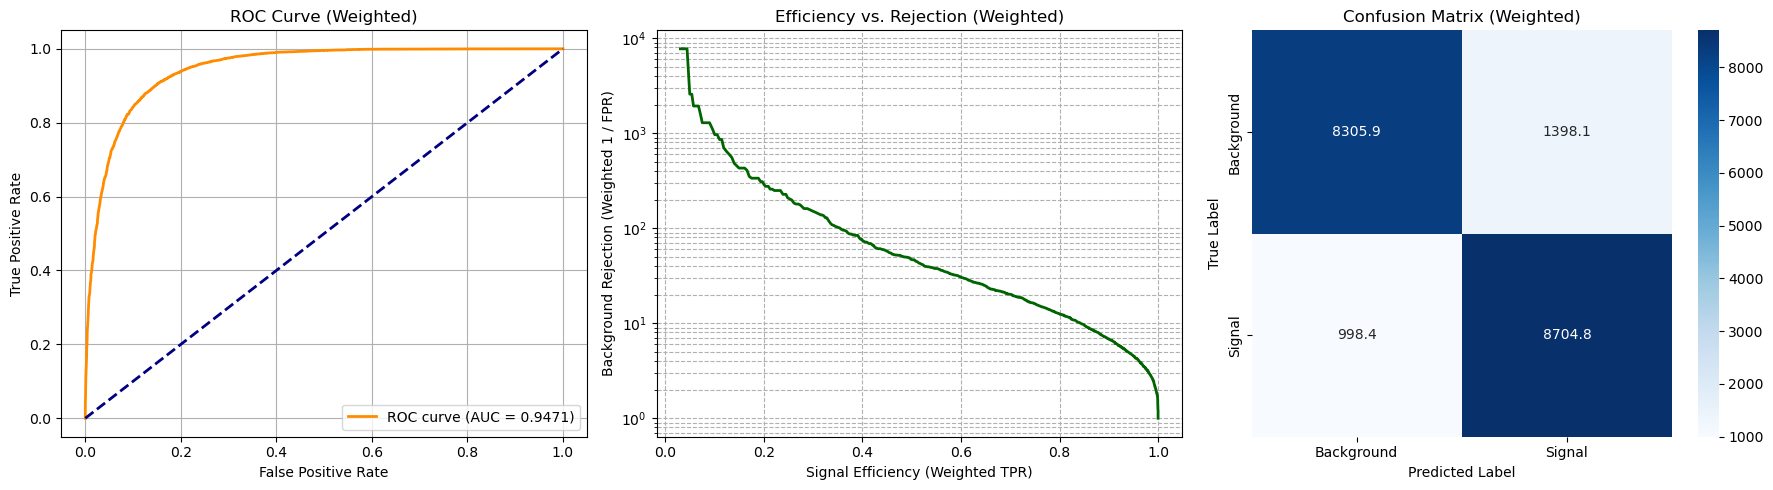


SCORING AND SAVING FULL DATASETS (GDNN)
Generating GDNN scores for 116824 events...


/tmp/ipykernel_23694/869830985.py:134: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gdnn_model.pth"))


 -> Saved successfully to: gdnn_combined_results/df_sig_reco_m_cut_no_sub.parquet
Generating GDNN scores for 77246 events...
 -> Saved successfully to: gdnn_combined_results/df_bkg_reco_m_cut_no_sub.parquet

All GDNN processing complete.


In [33]:
# ==========================================
# 4. Evaluation Function
# ==========================================
def evaluate_combined_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()
    all_labels = []
    all_probas = []
    all_weights = []

    with torch.no_grad():
        for xg, xd, labels, weights in data_loader:
            xg = xg.to(device)
            xd = xd.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(xg, xd)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy())

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten()

    # 1. Performance Statistics
    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET (with event weights)\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    # 2. ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Weighted)')
    plt.legend(loc="lower right")
    plt.grid(True)

    # 3. Efficiency vs Rejection
    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
        
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log')
    plt.xlabel('Signal Efficiency (Weighted TPR)')
    plt.ylabel('Background Rejection (Weighted 1 / FPR)')
    plt.title('Efficiency vs. Rejection (Weighted)')
    plt.grid(True, which="both", ls="--")

    # 4. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

# --- Execution ---
print("\nEvaluating best GDNN model on Test Set...")
gdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gdnn_model.pth"))
evaluate_combined_model(gdnn_model, test_loader, DEVICE)

# ==========================================
# 5. Score Entire Datasets and Save to Parquet
# ==========================================
import os

def score_and_save_gdnn_dataset(df, X_gnn_raw, X_dnn_raw, scaler_gnn, scaler_dnn, model, device, output_path, batch_size=BATCH_SIZE):
    """
    Applies the trained GDNN model to the full dataset, adds the scores as a new column,
    and saves the result to a Parquet file.
    """
    print(f"Generating GDNN scores for {len(df)} events...")
    
    # 1a. Scale GNN Features (Preserving 0-padding)
    N, M, F = X_gnn_raw.shape
    X_gnn_flat = X_gnn_raw.reshape(-1, F).copy()
    is_real = ~np.all(X_gnn_flat == 0, axis=1)
    
    if np.any(is_real):
        X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
    X_gnn_flat[~is_real] = 0.0 
    X_gnn_scaled = X_gnn_flat.reshape(N, M, F)
    
    # 1b. Scale DNN Features
    X_dnn_scaled = scaler_dnn.transform(X_dnn_raw)
    
    # 2. Create DataLoader
    tensor_ds = TensorDataset(
        torch.tensor(X_gnn_scaled, dtype=torch.float32),
        torch.tensor(X_dnn_scaled, dtype=torch.float32)
    )
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    # 3. Get predictions
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for xg, xd in loader:
            xg = xg.to(device, non_blocking=True)
            xd = xd.to(device, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                outputs = model(xg, xd)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    # 4. Add the scores to a copy of the dataframe
    df_scored = df.copy() 
    df_scored['gdnn_score'] = np.array(all_probas).flatten()
    
    # 5. Save to Parquet
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS (GDNN)\n" + "="*60)

# Ensure the model is using the best weights from Early Stopping
gdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gdnn_model.pth"))

#Score Signal Dataset
# Assuming df_sig_dr_1, xg_sig, and xd_sig are in memory from your earlier data processing steps
df_sig_gdnn_scored = score_and_save_gdnn_dataset(
    df=df_sig_gnn_scored, 
    X_gnn_raw=xg_sig, 
    X_dnn_raw=xd_sig,
    scaler_gnn=scaler_gnn, 
    scaler_dnn=scaler_dnn,
    model=gdnn_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_SIG),
    batch_size=BATCH_SIZE
)

# Score Background Dataset
df_bkg_gdnn_scored = score_and_save_gdnn_dataset(
    df=df_bkg_gnn_scored, 
    X_gnn_raw=xg_bg, 
    X_dnn_raw=xd_bg,
    scaler_gnn=scaler_gnn, 
    scaler_dnn=scaler_dnn,
    model=gdnn_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_BKG),
    batch_size=BATCH_SIZE
)

print("\nAll GDNN processing complete.")

In [ ]:
# Transformer

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau # Added LR Scheduler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

OUTPUT_DIR = 'transformer_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assume BATCH_SIZE is defined in your global environment (e.g., BATCH_SIZE = 1024)
BATCH_SIZE = 128

# ==========================================
# 1. Data Scaling & DataLoaders
# ==========================================
print("Setting up DataLoaders...")

# Assuming xg_sig, xg_bg, xd_sig, xd_bg, y_sig, y_bg, w_sig, w_bg are available 
# from load_and_process_new_dataset() as mentioned in your setup.

X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
X_dnn_all = np.concatenate([xd_sig, xd_bg], axis=0)
y_all = np.concatenate([y_sig, y_bg], axis=0)
w_all = np.concatenate([w_sig, w_bg], axis=0)

# 1a. Scale DNN Features (Included for dataset alignment, even if unused by the model)
scaler_dnn = StandardScaler()
X_dnn_all_scaled = scaler_dnn.fit_transform(X_dnn_all)

# 1b. Scale GNN/Transformer Features (Masking out zero-padded particles)
N, M, F = X_gnn_all.shape
X_gnn_flat = X_gnn_all.reshape(-1, F)
is_real = ~np.all(X_gnn_flat == 0, axis=1) # Boolean mask for real tracks

scaler_gnn = StandardScaler()
scaler_gnn.fit(X_gnn_flat[is_real])
X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
X_gnn_flat[~is_real] = 0.0 # Ensure padding remains exactly zero
X_gnn_all_scaled = X_gnn_flat.reshape(N, M, F)

# 1c. Data Splitting (Train 80% / Val 10% / Test 10%)
print(f"Total Combined dataset size: {len(y_all)} events")
indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# 1d. Create PyTorch Datasets (Yielding: x_gnn, x_dnn, y, w)
train_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[train_idx].copy(), dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[train_idx].copy(), dtype=torch.float32), 
    torch.tensor(y_all[train_idx].copy(), dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[train_idx].copy(), dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[val_idx].copy(), dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[val_idx].copy(), dtype=torch.float32), 
    torch.tensor(y_all[val_idx].copy(), dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[val_idx].copy(), dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[test_idx].copy(), dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[test_idx].copy(), dtype=torch.float32), 
    torch.tensor(y_all[test_idx].copy(), dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[test_idx].copy(), dtype=torch.float32).view(-1, 1)
)

# num_workers=0 avoids multiprocessing segfaults for in-memory datasets
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)


# ==========================================
# 2. Model Definition
# ==========================================
class ParticleTransformer(nn.Module):
    def __init__(self, n_features, d_model=128, nhead=4, num_layers=3, dim_feedforward=256, dropout=0.1):
        super(ParticleTransformer, self).__init__()
        
        self.embedding = nn.Linear(n_features, d_model)
        self.norm_in = nn.LayerNorm(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, 
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.cls_head = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1) # Logits
        )

    def forward(self, x, mask=None):
        x = self.embedding(x)
        x = self.norm_in(x)
        x = self.transformer_encoder(x, src_key_padding_mask=mask) 
        
        if mask is not None:
            mask_float = (~mask).float().unsqueeze(-1) 
            x = x * mask_float 
            sum_embeddings = torch.sum(x, dim=1)
            count_valid = torch.sum(mask_float, dim=1)
            pooled = sum_embeddings / (count_valid + 1e-6)
        else:
            pooled = torch.mean(x, dim=1)
            
        return self.cls_head(pooled)

class AutoMaskedTransformer(nn.Module):
    def __init__(self, transformer_model):
        super(AutoMaskedTransformer, self).__init__()
        self.model = transformer_model
        
    def forward(self, x):
        # A particle is padding if all its features are exactly 0.0
        mask = (x == 0).all(dim=-1)
        return self.model(x, mask=mask)

# Initialize Model
base_transformer = ParticleTransformer(n_features=X_gnn_all_scaled.shape[2]) # Should be 4
transformer_model = AutoMaskedTransformer(base_transformer).to(DEVICE)

# Explicitly keeping torch.compile DISABLED to prevent LLVM thread conflicts
# transformer_model = torch.compile(transformer_model)

optimizer = optim.Adam(transformer_model.parameters(), lr=0.001)

# --- ADDED: Initialize the Scheduler ---
# Trigger after 2 epochs of no improvement, halving the learning rate
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3)

scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    return (loss * weight).mean()


# ==========================================
# 3. Training Loop with Early Stopping
# ==========================================
print("\nStarting Transformer Training...")
EPOCHS = 100 
best_val_loss = float('inf')
patience = 8
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- Training ---
    transformer_model.train()
    train_loss = 0
    
    for xg, xd, y_batch, w_batch in train_loader:
        xg = xg.to(DEVICE, non_blocking=True)
        # We ignore xd here since this is a standalone Transformer
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = transformer_model(xg)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * xg.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation ---
    transformer_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for xg, xd, y_batch, w_batch in val_loader:
            xg = xg.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                out = transformer_model(xg)
                loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * xg.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # --- ADDED: Step the Scheduler ---
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(transformer_model.state_dict(), f"{OUTPUT_DIR}/best_transformer_only.pth")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped at epoch {epoch+1}.")
            break

print("Training Complete!")


# ==========================================
# 4. Evaluation Function
# ==========================================
def evaluate_transformer_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  
    all_labels = []
    all_probas = []
    all_weights = [] 

    with torch.no_grad():
        for xg, xd, labels, weights in data_loader:
            xg = xg.to(device)
            # xd is ignored for Transformer
            
            with torch.amp.autocast('cuda'):
                outputs = model(xg)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) 

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten() 

    # 1. Performance Statistics 
    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET (with event weights)\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    # 2. ROC Curve 
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Weighted)')
    plt.legend(loc="lower right")
    plt.grid(True)

    # 3. Efficiency vs Rejection 
    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
        
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log')
    plt.xlabel('Signal Efficiency (Weighted TPR)')
    plt.ylabel('Background Rejection (Weighted 1 / FPR)')
    plt.title('Efficiency vs. Rejection (Weighted)')
    plt.grid(True, which="both", ls="--")

    # 4. Confusion Matrix 
    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

# --- Execution ---
print("\nEvaluating best Transformer model on Test Set...")
transformer_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_transformer_only.pth"))
evaluate_transformer_model(transformer_model, test_loader, DEVICE)


# ==========================================
# 5. Score Entire Datasets and Save to Parquet
# ==========================================
def score_and_save_transformer_dataset(df, X_gnn_raw, scaler_gnn, model, device, output_path, batch_size=BATCH_SIZE):
    """
    Applies the trained Transformer model to the full dataset, adds the scores as a new column,
    and saves the result to a Parquet file.
    """
    print(f"Generating Transformer scores for {len(df)} events...")
    
    # 1. Scale GNN Features (Preserving 0-padding)
    N, M, F = X_gnn_raw.shape
    X_gnn_flat = X_gnn_raw.reshape(-1, F).copy()
    is_real = ~np.all(X_gnn_flat == 0, axis=1)
    
    if np.any(is_real):
        X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
    X_gnn_flat[~is_real] = 0.0 
    X_gnn_scaled = X_gnn_flat.reshape(N, M, F)
    
    # 2. Create DataLoader (Only GNN needed for Transformer)
    tensor_ds = TensorDataset(
        torch.tensor(X_gnn_scaled, dtype=torch.float32)
    )
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    # 3. Get predictions
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for xg_batch in loader:
            # DataLoader returns a tuple of length 1, extract the tensor
            xg = xg_batch[0].to(device, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                outputs = model(xg)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    # 4. Add the scores to a copy of the dataframe
    df_scored = df.copy() 
    df_scored['transformer_score'] = np.array(all_probas).flatten()
    
    # 5. Save to Parquet
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS (TRANSFORMER)\n" + "="*60)

# Ensure the model is using the best weights from Early Stopping
transformer_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_transformer_only.pth"))

# Score Signal Dataset
# Assuming df_sig is your original signal dataframe from the setup step
df_sig_transformer_scored = score_and_save_transformer_dataset(
    df=df_sig, 
    X_gnn_raw=xg_sig, 
    scaler_gnn=scaler_gnn, 
    model=transformer_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_SIG),
    batch_size=BATCH_SIZE
)

# Score Background Dataset
# Assuming df_bkg is your original background dataframe from the setup step
df_bkg_transformer_scored = score_and_save_transformer_dataset(
    df=df_bkg, 
    X_gnn_raw=xg_bg, 
    scaler_gnn=scaler_gnn, 
    model=transformer_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_BKG),
    batch_size=BATCH_SIZE
)

print("\nAll Transformer processing complete.")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau # Added LR Scheduler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

OUTPUT_DIR = 'tdnn_combined_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assume BATCH_SIZE is defined in your global environment (e.g., BATCH_SIZE = 1024)
BATCH_SIZE = 128

# ==========================================
# 1. Data Scaling & DataLoaders
# ==========================================
print("Setting up DataLoaders...")

# Assuming xg_sig, xg_bg, xd_sig, xd_bg, y_sig, y_bg, w_sig, w_bg are available 
# from load_and_process_new_dataset() as mentioned in your setup.

X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
X_dnn_all = np.concatenate([xd_sig, xd_bg], axis=0)
y_all = np.concatenate([y_sig, y_bg], axis=0)
w_all = np.concatenate([w_sig, w_bg], axis=0)

# 1a. Scale DNN Features
scaler_dnn = StandardScaler()
X_dnn_all_scaled = scaler_dnn.fit_transform(X_dnn_all)

# 1b. Scale GNN/Transformer Features (Masking out zero-padded particles)
N, M, F = X_gnn_all.shape
X_gnn_flat = X_gnn_all.reshape(-1, F)
is_real = ~np.all(X_gnn_flat == 0, axis=1) # Boolean mask for real tracks

scaler_gnn = StandardScaler()
scaler_gnn.fit(X_gnn_flat[is_real])
X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
X_gnn_flat[~is_real] = 0.0 # Ensure padding remains exactly zero
X_gnn_all_scaled = X_gnn_flat.reshape(N, M, F)

# 1c. Data Splitting (Train 80% / Val 10% / Test 10%)
print(f"Total Combined dataset size: {len(y_all)} events")
indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# 1d. Create PyTorch Datasets
train_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[train_idx].copy(), dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[train_idx].copy(), dtype=torch.float32), 
    torch.tensor(y_all[train_idx].copy(), dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[train_idx].copy(), dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[val_idx].copy(), dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[val_idx].copy(), dtype=torch.float32), 
    torch.tensor(y_all[val_idx].copy(), dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[val_idx].copy(), dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[test_idx].copy(), dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[test_idx].copy(), dtype=torch.float32), 
    torch.tensor(y_all[test_idx].copy(), dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[test_idx].copy(), dtype=torch.float32).view(-1, 1)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)


# ==========================================
# 2. Model Definition (Combined Transformer + DNN)
# ==========================================

# --- 2A. Transformer Feature Extractor ---
class ParticleTransformerExtractor(nn.Module):
    def __init__(self, n_features, d_model=128, nhead=4, num_layers=3, dim_feedforward=256, dropout=0.1, output_latent_dim=24):
        super(ParticleTransformerExtractor, self).__init__()
        
        self.embedding = nn.Linear(n_features, d_model)
        self.norm_in = nn.LayerNorm(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, 
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Project the pooled transformer embedding down to a dense vector (e.g., 24-dim)
        self.latent_proj = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, output_latent_dim),
            nn.ReLU()
        )

    def forward(self, x, mask=None):
        x = self.embedding(x)
        x = self.norm_in(x)
        x = self.transformer_encoder(x, src_key_padding_mask=mask) 
        
        # Global Mean Pooling (Mask-aware)
        if mask is not None:
            mask_float = (~mask).float().unsqueeze(-1) 
            x = x * mask_float 
            sum_embeddings = torch.sum(x, dim=1)
            count_valid = torch.sum(mask_float, dim=1)
            pooled = sum_embeddings / (count_valid + 1e-6)
        else:
            pooled = torch.mean(x, dim=1)
            
        # Return the dense embedding, NOT logits
        return self.latent_proj(pooled)

class AutoMaskedTransformerExtractor(nn.Module):
    def __init__(self, transformer_extractor):
        super(AutoMaskedTransformerExtractor, self).__init__()
        self.model = transformer_extractor
        
    def forward(self, x):
        # A particle is padding if all its features are exactly 0.0
        mask = (x == 0).all(dim=-1)
        return self.model(x, mask=mask)

# --- 2B. Standard DNN Block ---
class DNNBlock(nn.Module):
    def __init__(self, input_dim):
        super(DNNBlock, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.15),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.15),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1) # Final Output Logits
        )
    def forward(self, x):
        return self.net(x)

# --- 2C. Unified Transformer-DNN Model ---
class TDNN(nn.Module):
    def __init__(self, n_transformer_features, n_dnn_features, transformer_latent_dim=24):
        super(TDNN, self).__init__()
        
        # Transformer Branch
        base_transformer = ParticleTransformerExtractor(n_features=n_transformer_features, output_latent_dim=transformer_latent_dim)
        self.transformer_branch = AutoMaskedTransformerExtractor(base_transformer)
        
        # DNN Branch (Takes concatenated Transformer Embedding + DNN Features)
        combined_dim = transformer_latent_dim + n_dnn_features
        self.dnn_branch = DNNBlock(combined_dim)
        
    def forward(self, x_trans, x_dnn):
        # 1. Get Track Embeddings from Transformer
        trans_embedding = self.transformer_branch(x_trans)
        
        # 2. Concatenate with High-Level Event Kinematics
        combined_features = torch.cat([trans_embedding, x_dnn], dim=1)
        
        # 3. Final Prediction
        logits = self.dnn_branch(combined_features)
        return logits

# ==========================================
# 3. Model Initialization
# ==========================================
transformer_feats = X_gnn_all_scaled.shape[2] # Should be 4
dnn_feats = X_dnn_all_scaled.shape[1]         # Should be 25

tdnn_model = TDNN(
    n_transformer_features=transformer_feats, 
    n_dnn_features=dnn_feats, 
    transformer_latent_dim=24
).to(DEVICE)

# Note: torch.compile purposefully OMITTED to avoid segmentation faults!

optimizer = optim.Adam(tdnn_model.parameters(), lr=0.001)

# --- ADDED: Initialize the Scheduler ---
# Trigger after 2 epochs of no improvement, halving the learning rate
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3)

scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    return (loss * weight).mean()


# ==========================================
# 4. Training Loop with Early Stopping
# ==========================================
print("\nStarting Combined TDNN (Transformer+DNN) Training...")
EPOCHS = 100 
best_val_loss = float('inf')
patience = 8
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- Training ---
    tdnn_model.train()
    train_loss = 0
    
    for x_trans, x_dnn, y_batch, w_batch in train_loader:
        x_trans = x_trans.to(DEVICE, non_blocking=True)
        x_dnn = x_dnn.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = tdnn_model(x_trans, x_dnn)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * x_trans.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation ---
    tdnn_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x_trans, x_dnn, y_batch, w_batch in val_loader:
            x_trans = x_trans.to(DEVICE, non_blocking=True)
            x_dnn = x_dnn.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                out = tdnn_model(x_trans, x_dnn)
                loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * x_trans.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # --- ADDED: Step the Scheduler ---
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(tdnn_model.state_dict(), f"{OUTPUT_DIR}/best_tdnn_model.pth")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped at epoch {epoch+1}.")
            break

print("Training Complete!")


# ==========================================
# 5. Evaluation 
# ==========================================
def evaluate_combined_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  
    all_labels = []
    all_probas = []
    all_weights = [] 

    with torch.no_grad():
        for x_trans, x_dnn, labels, weights in data_loader:
            x_trans = x_trans.to(device)
            x_dnn = x_dnn.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(x_trans, x_dnn)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) 

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten() 

    # 1. Performance Statistics 
    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET (with event weights)\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    # 2. ROC Curve 
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve (Weighted)'); plt.legend(loc="lower right"); plt.grid(True)

    # 3. Signal Efficiency vs. Background Rejection 
    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log'); plt.xlabel('Signal Efficiency (Weighted TPR)'); plt.ylabel('Background Rejection (Weighted 1 / FPR)'); plt.title('Efficiency vs. Rejection (Weighted)'); plt.grid(True, which="both", ls="--")

    # 4. Confusion Matrix 
    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)'); plt.ylabel('True Label'); plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

# --- Execution ---
print("\nEvaluating best TDNN model on Test Set...")
tdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_tdnn_model.pth"))
evaluate_combined_model(tdnn_model, test_loader, DEVICE)


# ==========================================
# 6. Score Entire Datasets and Save to Parquet
# ==========================================
def score_and_save_tdnn_dataset(df, X_gnn_raw, X_dnn_raw, scaler_gnn, scaler_dnn, model, device, output_path, batch_size=BATCH_SIZE):
    """
    Applies the trained TDNN model to the full dataset, adds the scores as a new column,
    and saves the result to a Parquet file.
    """
    print(f"Generating TDNN scores for {len(df)} events...")
    
    # 1a. Scale GNN/Transformer Features (Preserving 0-padding)
    N, M, F = X_gnn_raw.shape
    X_gnn_flat = X_gnn_raw.reshape(-1, F).copy()
    is_real = ~np.all(X_gnn_flat == 0, axis=1)
    
    if np.any(is_real):
        X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
    X_gnn_flat[~is_real] = 0.0 
    X_gnn_scaled = X_gnn_flat.reshape(N, M, F)
    
    # 1b. Scale DNN Features
    X_dnn_scaled = scaler_dnn.transform(X_dnn_raw)
    
    # 2. Create DataLoader
    tensor_ds = TensorDataset(
        torch.tensor(X_gnn_scaled, dtype=torch.float32),
        torch.tensor(X_dnn_scaled, dtype=torch.float32)
    )
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    # 3. Get predictions
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for xg, xd in loader:
            xg = xg.to(device, non_blocking=True)
            xd = xd.to(device, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                outputs = model(xg, xd)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    # 4. Add the scores to a copy of the dataframe
    df_scored = df.copy() 
    df_scored['tdnn_score'] = np.array(all_probas).flatten()
    
    # 5. Save to Parquet
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS (TDNN)\n" + "="*60)

# Ensure the model is using the best weights from Early Stopping
tdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_tdnn_model.pth"))

# Score Signal Dataset
df_sig_tdnn_scored = score_and_save_tdnn_dataset(
    df=df_sig, 
    X_gnn_raw=xg_sig, 
    X_dnn_raw=xd_sig,
    scaler_gnn=scaler_gnn, 
    scaler_dnn=scaler_dnn,
    model=tdnn_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_SIG),
    batch_size=BATCH_SIZE
)

# Score Background Dataset
df_bkg_tdnn_scored = score_and_save_tdnn_dataset(
    df=df_bkg, 
    X_gnn_raw=xg_bg, 
    X_dnn_raw=xd_bg,
    scaler_gnn=scaler_gnn, 
    scaler_dnn=scaler_dnn,
    model=tdnn_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_BKG),
    batch_size=BATCH_SIZE
)

print("\nAll TDNN processing complete.")